In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type, only_aut
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import main_load_data, select_CNS_samples, load_merged_samples, img_path, load_samples_out
import pandas as pd
from io import StringIO

In [3]:
load_merged_samples(True);

PCAWG
Total samples: 2778
248 samples are CN neutral (below 0.0016)
13 samples have low coverage (below 0.9510000000000001)
195 samples are blacklisted
Filtered samples: 2357
TRACERx
Total samples: 1428
1 samples are CN neutral (below 0.0011)
0 samples have low coverage (below 0.872)
248 samples do not have exact type
Filtered samples: 1179
TCGA_hg19
Total samples: 9868
948 samples are CN neutral (below 0.001)
1 samples have low coverage (below 0.948)
Filtered samples: 8919
Overlapping samples with PCAWG: 828
After overlap removal: 8275
Total samples: 11811


In [15]:
# TSV string
tsv_data = """
Source \tTotal samples\tCN neutral samples\tLow coverage samples\tOther\tFiltered samples
PCAWG\t2778\t248\t13\t195\t2375
TRACERx\t1428\t1\t0\t248\t1179
TCGA\t9868\t948\t1\t828\t8275
"""

# Create DataFrame
df = pd.read_csv(StringIO(tsv_data), sep='\t')
df

,Source,Total samples,CN neutral samples,Low coverage samples,Other,Filtered samples
0,PCAWG,2778,248,13,195,2375
1,TRACERx,1428,1,0,248,1179
2,TCGA,9868,948,1,828,8275


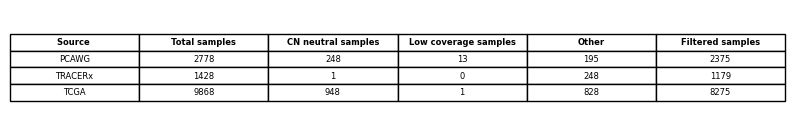

In [19]:
fig, ax = plt.subplots(figsize=(10, 1.5))  # Set the figure size
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Make the header and index bold
for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.set_text_props(weight='bold')

# Save the plot as a PDF
plt.savefig(f"{img_path}/sample_table.pdf",  bbox_inches='tight')

# Display the plot
plt.show()

In [20]:
tracerx_prim = load_samples_out("TRACERx_prim_samples.tsv")
print("primary", tracerx_prim.index.unique().shape[0])
tracerx_met = load_samples_out("TRACERx_met_samples.tsv")
print("metastatic", tracerx_met.index.unique().shape[0])
print("both", len(set(tracerx_prim.index.unique()) & set(tracerx_met.index.unique())))

primary 1428
metastatic 694
both 502


In [21]:
samples_df, cns_df = main_load_data("3MB")

In [22]:
samples_df["type"].value_counts().head(6).sum()

4686

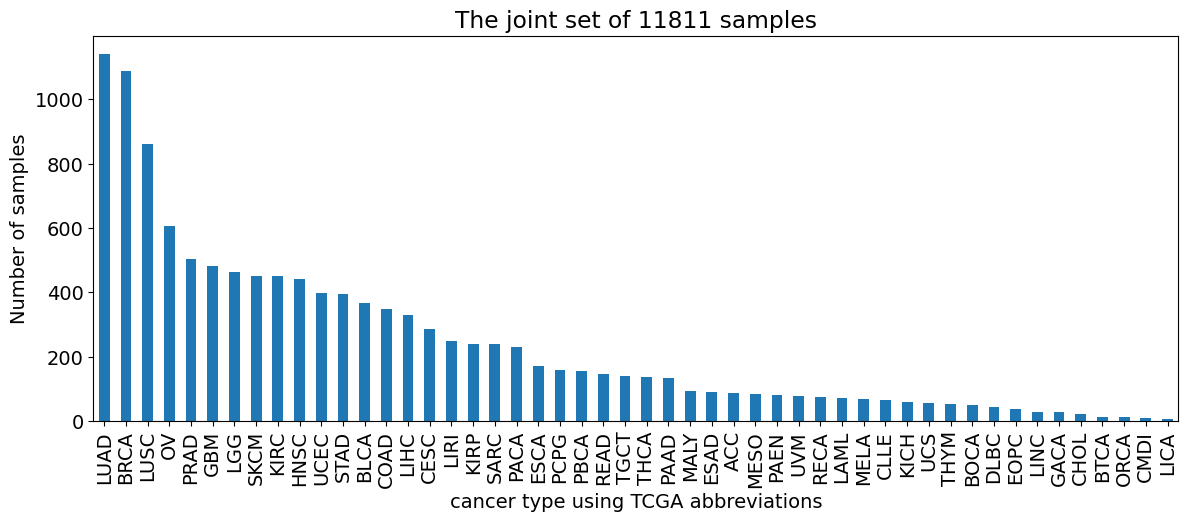

In [23]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("The joint set of {} samples".format(len(samples_df)))
plt.ylabel("Number of samples")
plt.xlabel("cancer type using TCGA abbreviations")

plt.savefig(f"{img_path}/cancer_types.png", bbox_inches="tight", dpi=200)
plt.savefig(f"{img_path}/cancer_types.pdf", bbox_inches="tight", dpi=200)

In [24]:
top_6 = samples_df["type"].value_counts().head(6).index
top_6_cns_df = [group_bins(get_cns_for_type(cns_df, samples_df, cancer_type)) for cancer_type in top_6]

Text(0.5, 1.0, 'Mean total copy number for the top 6 cancer types')

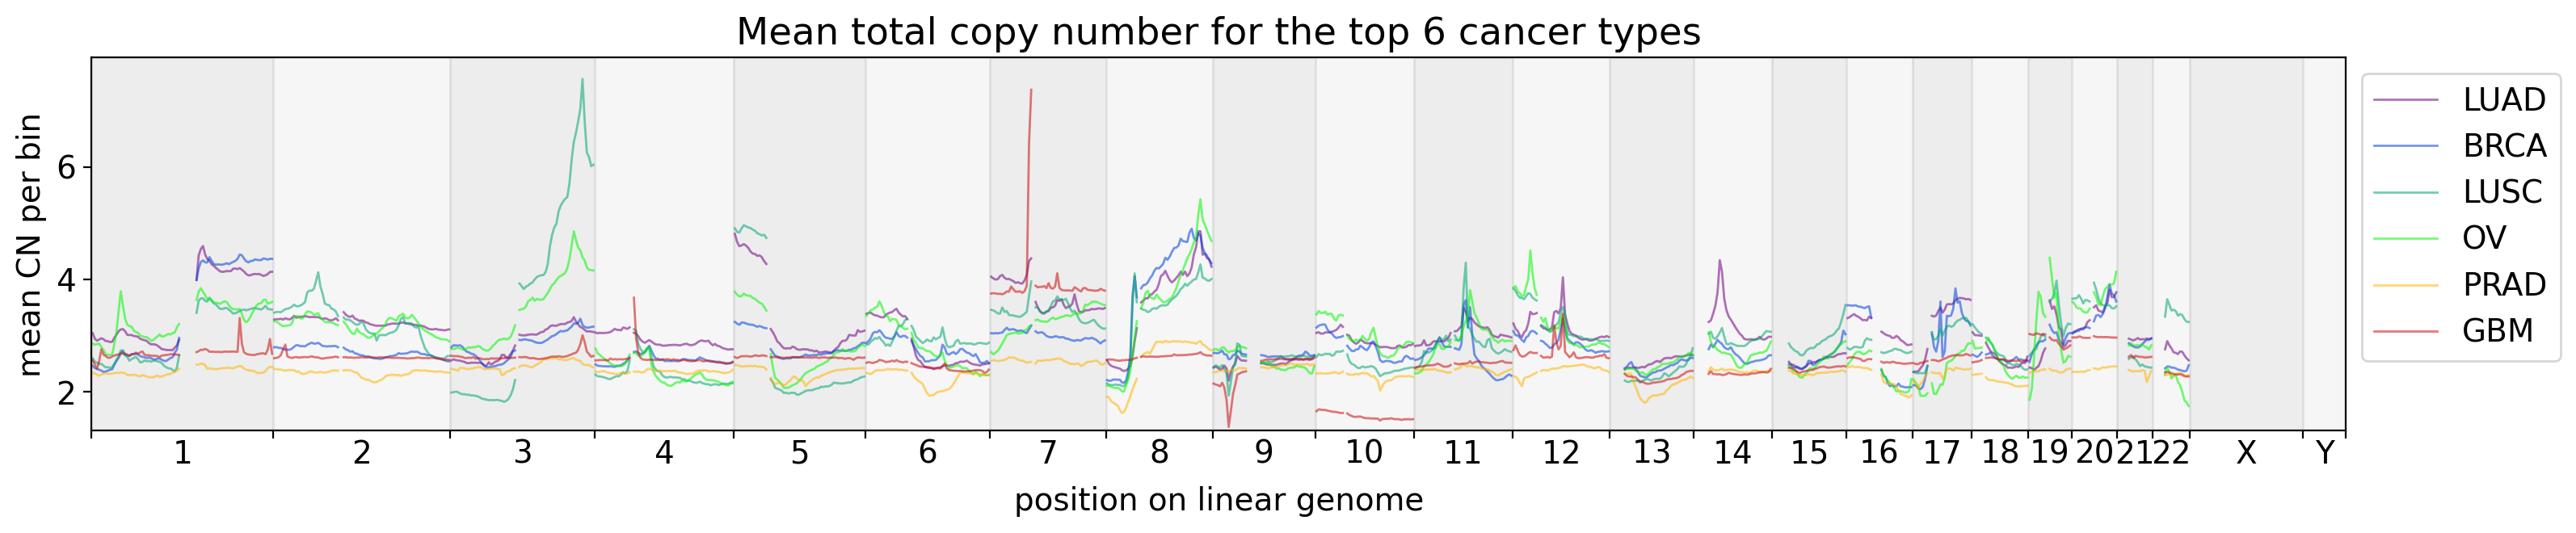

In [25]:
# double font size
plt.rcParams["font.size"] = 14
fig_lines([only_aut(x) for x in top_6_cns_df], top_6, column="total_cn", dpi=200)
# add title
plt.title("Mean total copy number for the top 6 cancer types")

C:\Users\adams\AppData\Local\Temp\ipykernel_46332\165816602.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")


(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

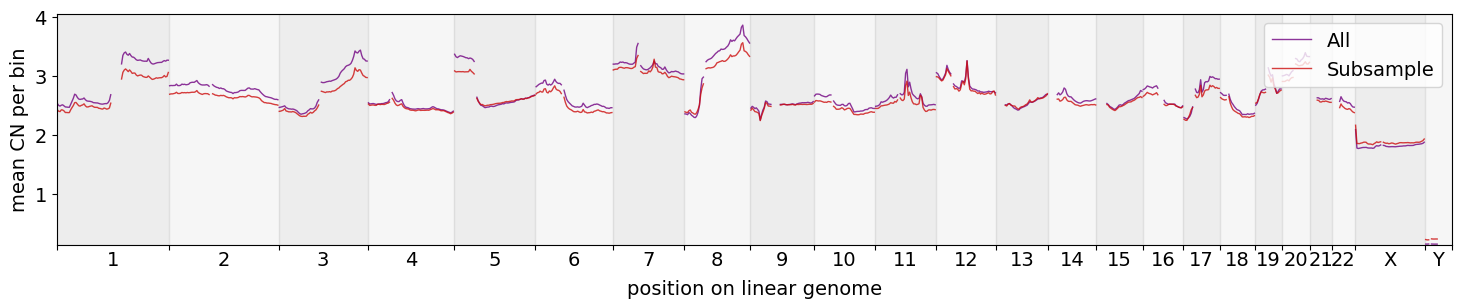

In [26]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True)).drop('type', axis=1).reset_index().set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn", dpi=100)